# 位置编码（Positional Encoding）

> **一句话总览**：注意力本身对顺序"失明"（置换不变），位置编码就是给每个 token 发一张"座位票"——正弦编码用不同频率的 sin/cos 生成**既唯一、又蕴含相对距离**的指纹，让模型知道"谁在谁前面、隔了多远"。

![](../src/positional-encoding-roadmap.svg)

本文笔记基于教材《Transformer技术纵深》第 7、8 章整理，配套哈佛 Annotated Transformer 源码与 8 个可运行实验。

> **配套阅读**：
> - 交互演示（推荐边读边玩）：[四项分解与投影破坏](../src/pe-attention-decomposition-guide/pe-attention-decomposition-guide.html)
> - 基础可视化：[位置编码基础指南](../src/positional-encoding-guide/positional-encoding-guide.html)

## 1. 为什么需要位置编码？——注意力的"失忆症"

自注意力的打分公式里，位置 $t, s$ 只是"求和用的编号"：

$$A_{t,s} = q_t^\top k_s = (x_t W_Q)(x_s W_K)^\top$$

把输入序列任意打乱，每个 token 的打分集合完全不变——这叫**置换不变性**。也就是说，没有位置编码的 Transformer 是一个**词袋模型**：

| 句子 | 词集合 | 注意力眼中的它 |
| --- | --- | --- |
| 猫追狗 | {猫, 追, 狗} | 完全相同 |
| 狗追猫 | {猫, 追, 狗} | 完全相同（语义却相反！） |

![](../src/transformer-8-1.jpg)

> 图：把"从上海到北京"当双 token 序列看。不引入位置信息，"上海出发、北京到达"和反过来的句子无法区分；引入**绝对**位置（知道"谁在第 1 位"）或**相对**位置（知道"两地相距多远、谁在前"）都能恢复语义。一切位置编码工作的出发点就一句话：**把顺序信息重新注入模型**。

## 2. 什么样的位置编码才是"好"编码

动手设计之前，先列一张"需求清单"——后面每个方案都能对着它打分：

| # | 性质 | 为什么需要 |
| --- | --- | --- |
| ① | **唯一性**：每个位置的编码各不相同 | 否则模型无法区分相邻 token |
| ② | **相对性**：任意两位置的编码差异只与距离有关 | "第 5 和第 8 个词的关系"应与"第 100 和第 103 个词的关系"一样，模型才能举一反三 |
| ③ | **有界且平滑**：取值有界、随距离平滑衰减 | 与词嵌入同量级、训练稳定；"远处更不重要"符合语言直觉 |
| ④ | **确定性可外推**：不训练、规则对任意长度成立 | 训练没见过的更长句子也能直接用

## 3. 位置编码的演化：从整数到正弦

朴素念头：直接把位置序号当数字输入不就行了？沿这条思路走五步，会自然推导出正弦编码：

| 方案 | 做法 | 问题 |
| --- | --- | --- |
| ① 整型 | 直接输入 0, 1, 2, … | 数值无界，远超词嵌入的 $[-1,1]$，训练被大数值淹没 |
| ② 乘常数 | $t/1000$ 缩到有界 | 第 990 和第 1000 个位置挤在一起，几乎无法区分 |
| ③ 归一化 | 压到 $[0,1]$：$t/n$ | 分辨率依赖句长：100 词的句子里相邻差 0.01，1000 词的句子里差 0.001——"一步"的含义飘忽不定 |
| ④ 二进制 | 把位置写成二进制，每个 bit 当一个维度 | 见下图：高位低频、低位高频，各维度"各走各的节拍"，很巧妙！但取值只有 0/1，**离散**、不可微、维度利用率低 |
| ⑤ 连续化 | 用 $\sin/\cos$ 替代 0/1，让每个维度以**不同频率**连续振荡 | ✅ 正弦位置编码，论文最终方案 |

![](../src/transformer-7-3.jpg)

> 图：4 位二进制表示 0~15。第 0 位（最低位）每步都翻转（频率最高），第 3 位（最高位）每 16 步才翻转一次（频率最低）——活脱脱一排"秒针、分针、时针"。把它**连续化**（0/1 换成平滑振荡的 sin/cos）就是第⑤步。

## 4. 正弦位置编码：公式、直觉与手算

$$PE_{(pos,\,2i)} = \sin\!\big(pos \cdot c_i\big), \qquad PE_{(pos,\,2i+1)} = \cos\!\big(pos \cdot c_i\big), \qquad c_i = 1/10000^{2i/d_{model}}$$

相邻的一对维度 $(2i,\,2i+1)$ 共享一个频率 $c_i$，分别用 sin 和 cos——就像同一根指针的纵坐标与横坐标。频率随 $i$ **几何递减**：波长从 $2\pi$ 一直拉长到 $10000\cdot 2\pi$。

**钟表类比**：$d_{model}$ 维编码就是一排 $\tfrac{d}{2}$ 个时钟——低维是"秒针"（频率高、转得快，负责精细区分相邻位置），高维是"时针"（频率低、转得慢，负责大范围粗定位）。读出所有指针的角度组合，就是当前位置独一无二的"指纹"。

In [1]:
# 实验 1：手算正弦编码（d_model=6，对应教材"新年快乐"的展开示例）
# 公式：PE(pos, 2i)=sin(pos·c_i)，PE(pos, 2i+1)=cos(pos·c_i)，c_i=10000^(-2i/6)
import numpy as np

d_model = 6
positions = np.arange(0, 6)
pairs = np.arange(0, d_model, 2)                      # 每对维度 (2i, 2i+1) 的 i = 0,1,2
c = 1.0 / 10000.0 ** (pairs / d_model)                # 三个频率
print(f"频率 c_i = {np.round(c, 4)}   （对应波长 2π/c ≈ {np.round(2*np.pi/c, 1)}）")
print()
header = "pos | " + " | ".join(f"PE[{2*i}] sin  PE[{2*i+1}] cos" for i in range(len(pairs)))
print(header)
print("-" * len(header))
for p in positions:
    row = []
    for ci in c:
        row += [np.sin(p * ci), np.cos(p * ci)]
    print(f" {p}  | " + " | ".join(f"{v:>+8.4f}" for v in row))
print()
print("观察：第 0/1 维（秒针）每走一步都大幅变化；第 4/5 维（时针）几乎不动——")
print("低维负责'细看相邻差别'，高维负责'远距离粗定位'。每行都是一个位置的专属指纹。")

频率 c_i = [1.     0.0464 0.0022]   （对应波长 2π/c ≈ [   6.3  135.4 2916.4]）

pos | PE[0] sin  PE[1] cos | PE[2] sin  PE[3] cos | PE[4] sin  PE[5] cos
------------------------------------------------------------------------
 0  |  +0.0000 |  +1.0000 |  +0.0000 |  +1.0000 |  +0.0000 |  +1.0000
 1  |  +0.8415 |  +0.5403 |  +0.0464 |  +0.9989 |  +0.0022 |  +1.0000
 2  |  +0.9093 |  -0.4161 |  +0.0927 |  +0.9957 |  +0.0043 |  +1.0000
 3  |  +0.1411 |  -0.9900 |  +0.1388 |  +0.9903 |  +0.0065 |  +1.0000
 4  |  -0.7568 |  -0.6536 |  +0.1846 |  +0.9828 |  +0.0086 |  +1.0000
 5  |  -0.9589 |  +0.2837 |  +0.2300 |  +0.9732 |  +0.0108 |  +0.9999

观察：第 0/1 维（秒针）每走一步都大幅变化；第 4/5 维（时针）几乎不动——
低维负责'细看相邻差别'，高维负责'远距离粗定位'。每行都是一个位置的专属指纹。


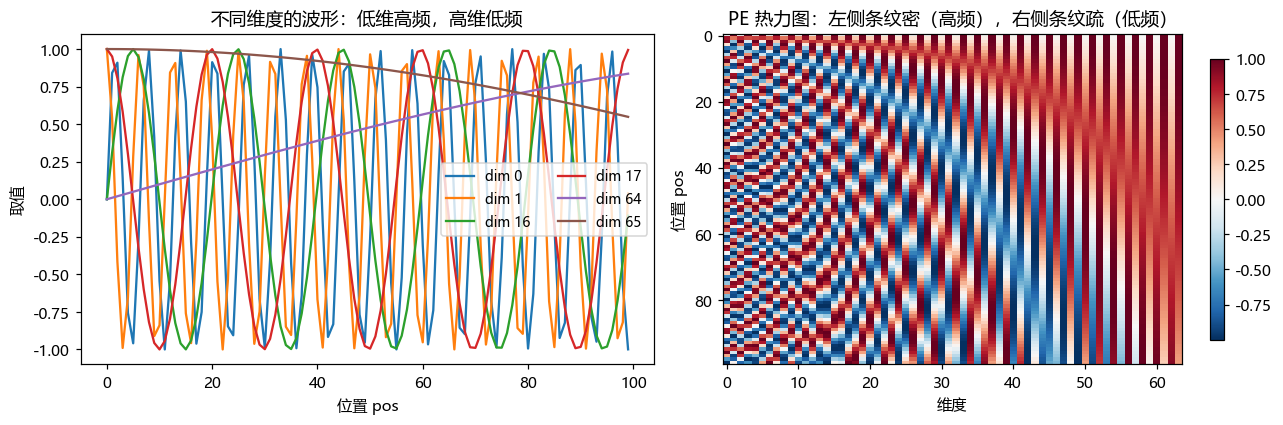

In [2]:
# 实验 2：画出正弦编码的"真面目"——低维波形 + 全景热力图
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

d_model, max_len = 128, 100
pos = np.arange(max_len)[:, None]                                  # (max_len, 1)
i2 = np.arange(0, d_model, 2)[None, :]                             # (1, d_model/2)
angles = pos / 10000 ** (i2 / d_model)                             # 广播 → (max_len, d_model/2)
pe = np.zeros((max_len, d_model))
pe[:, 0::2] = np.sin(angles)                                       # 偶数维 sin
pe[:, 1::2] = np.cos(angles)                                       # 奇数维 cos

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dim in [0, 1, 16, 17, 64, 65]:
    axes[0].plot(pe[:, dim], label=f"dim {dim}")
axes[0].set_title("不同维度的波形：低维高频，高维低频")
axes[0].set_xlabel("位置 pos")
axes[0].set_ylabel("取值")
axes[0].legend(ncol=2, fontsize=9)
im = axes[1].imshow(pe[:100, :64], aspect="auto", cmap="RdBu_r")
axes[1].set_title("PE 热力图：左侧条纹密（高频），右侧条纹疏（低频）")
axes[1].set_xlabel("维度")
axes[1].set_ylabel("位置 pos")
fig.colorbar(im, ax=axes[1], shrink=0.85)
plt.tight_layout()
plt.show()

## 5. 两大关键性质：唯一指纹与相对位置

正弦编码被选中，靠的是两条可以**数学证明**的性质。

**性质一：每个位置的编码唯一。** 多列频率互异的振荡波叠加，不同位置的相位组合不会重合——这是"指纹"的含义。

**性质二：相对位置可以线性算出。** 用和角公式 $\sin(\alpha+\beta)=\sin\alpha\cos\beta+\cos\alpha\sin\beta$ 可以证明：每对 $(2i, 2i+1)$ 平面里，位置前进 $k$ 等价于把二维向量**旋转** $k \cdot c_i$ 弧度——$PE_{t+k}$ 是 $PE_t$ 的线性变换。

由此得到整篇最重要的式子（教材式 7-6）——两个位置编码的**内积只依赖距离**：

$$\langle PE_t,\ PE_{t+k}\rangle \;=\; \sum_{i=0}^{d/2-1} \cos\big(\omega_i (t - s)\big) \;=\; \sum_i \cos(\omega_i k)$$

两个推论：① 内积与绝对位置 $t$ 无关、只依赖相对距离 $k$（平移不变）；② 各频率项正负抵消，内积随 $|k|$ 增大**平滑衰减到 0**（远程衰减）——"离得越远的词，位置上越不相关"，与语言直觉一致。

![](../src/transformer-7-5.jpg)

> 图：固定相对位移 $k$（0, 16, 32, …, 80）、改变绝对位置 $t$，编码曲线只是整体平移、形状不变——"位移不变"的直接展示。

四条曲线（t=0/50/100/150）的最大偏差：8.88e-16  → 数值上严格重合，平移不变成立
k=0 时内积 = 1.0000（自己和自己最像）；k=100 时已衰减到 +0.4864（远程衰减）


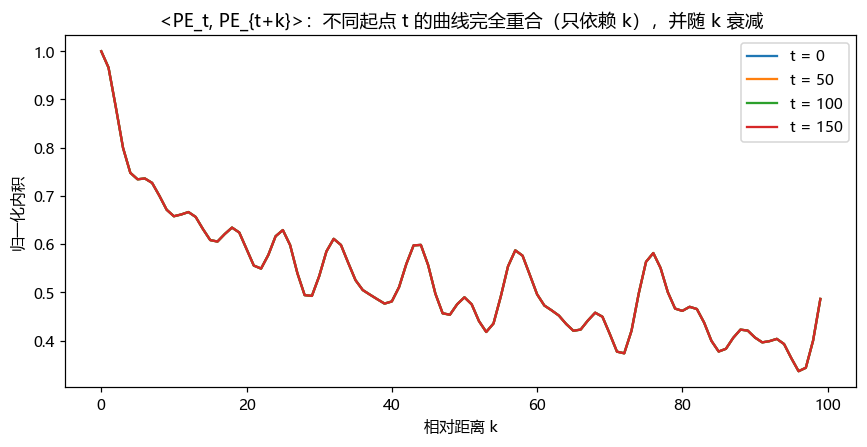

In [3]:
# 实验 3：验证 <PE_t, PE_{t+k}> 只依赖 k，且随 |k| 远程衰减
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

d_model, max_len = 64, 256
pos = np.arange(max_len)[:, None]
angles = pos / 10000 ** (np.arange(0, d_model, 2)[None, :] / d_model)
pe = np.zeros((max_len, d_model))
pe[:, 0::2] = np.sin(angles)
pe[:, 1::2] = np.cos(angles)
pe = pe / np.linalg.norm(pe, axis=1, keepdims=True)   # 归一化便于比较形状

K = 100
starts = [0, 50, 100, 150]
G = np.array([[pe[t] @ pe[t + k] for k in range(K)] for t in starts])

fig, ax = plt.subplots(figsize=(8, 4.2))
for t, g in zip(starts, G):
    ax.plot(g, label=f"t = {t}")
ax.set_title("<PE_t, PE_{t+k}>：不同起点 t 的曲线完全重合（只依赖 k），并随 k 衰减")
ax.set_xlabel("相对距离 k")
ax.set_ylabel("归一化内积")
ax.legend()
plt.tight_layout()
plt.show()

dev = np.max(np.abs(G - G[0]))
print(f"四条曲线（t=0/50/100/150）的最大偏差：{dev:.2e}  → 数值上严格重合，平移不变成立")
print(f"k=0 时内积 = {G[0, 0]:.4f}（自己和自己最像）；k=100 时已衰减到 {G[0, -1]:+.4f}（远程衰减）")

In [4]:
# 实验 4：验证"PE_{t+k} 是 PE_t 的旋转"——每对维度是一个 2D 旋转
import numpy as np

d_model = 8
c = 1.0 / 10000.0 ** (np.arange(0, d_model, 2) / d_model)     # 各对维度的角速度


def pe_of(t):
    '''位置 t 的编码（d_model=8）：每对维度是角度 t·c_i 在单位圆上的坐标。'''
    v = np.zeros(d_model)
    v[0::2] = np.sin(t * c)
    v[1::2] = np.cos(t * c)
    return v


t, k = 37, 5                                   # 任取起点和位移
max_err = 0.0
for i, ci in enumerate(c):
    a = pe_of(t)[2 * i:2 * i + 2]              # (sin, cos) = 角度 t·c_i 的坐标
    b = pe_of(t + k)[2 * i:2 * i + 2]          # 前进 k 步 = 角度加 k·c_i
    R = np.array([[np.cos(k * ci), np.sin(k * ci)],
                  [-np.sin(k * ci), np.cos(k * ci)]])   # 对应的 2D 旋转矩阵
    max_err = max(max_err, np.linalg.norm(b - R @ a))

print(f"取 t={t}, k={k}，逐对维度用 2D 旋转矩阵把 PE_t 转过去：")
print(f"与真实 PE_{{t+k}} 的最大误差 = {max_err:.2e}")
print()
print("结论：'位置前进 k 步' = '每对 (sin, cos) 平面旋转 k·c_i'——")
print("这正是 RoPE（旋转位置编码）思想的雏形：把相对位置直接做成旋转。")

取 t=37, k=5，逐对维度用 2D 旋转矩阵把 PE_t 转过去：
与真实 PE_{t+k} 的最大误差 = 1.24e-16

结论：'位置前进 k 步' = '每对 (sin, cos) 平面旋转 k·c_i'——
这正是 RoPE（旋转位置编码）思想的雏形：把相对位置直接做成旋转。


## 6. 相加还是拼接？——以及 √d_model 的秘密

拿到位置向量 $p_t$ 后怎么和词嵌入 $x_t$ 合并？两种候选：

![](../src/transformer-7-6.jpg)

- **拼接** $[x_t; p_t]$：信息零损失，但维度翻倍、参数翻倍；
- **相加** $x_t + p_t$：维度不变、零参数——但会不会把两种信息"搅在一起"分不清？

答案是：只要后续投影 $W$ 是自由训练的，**拼接与相加在表达力上等价**。把拼接权重按行分块 $W = \begin{bmatrix} W_x \\ W_p \end{bmatrix}$ 代入：

$$[x_t;\, p_t]\,W \;=\; x_t W_x + p_t W_p$$

即"相加"相当于提前固定了 $W_x = W_p = I$ 的拼接；训练中 $W$ 完全可以学着把混在一起的两种成分重新分离。相加以极小代价拿到几乎同样的表达力，Transformer 因此选了它。下面数值验证这个恒等式。

**√d_model 的秘密**：词嵌入通常初始化后再乘 $\sqrt{d_{model}}$，而正弦编码每维取值在 $[-1,1]$、整体模长约为 $\sqrt{d_{model}/2}$——乘 $\sqrt{d_{model}}$ 后两者恰好同量级，谁也不会淹没谁。

In [5]:
# 实验 5：验证"拼接后投影" ≡ "相加后按分块权重投影"
import numpy as np

rng = np.random.default_rng(0)
d, dp = 4, 4                       # 词嵌入维度 / 位置编码维度
x = rng.normal(size=d)
p = rng.normal(size=dp)

W_concat = rng.normal(size=(d + dp, 3))   # 拼接方案的权重（上 4 行作用在 x，下 4 行作用在 p）
W_x, W_p = W_concat[:d], W_concat[d:]     # 分块视角

lhs = np.concatenate([x, p]) @ W_concat   # 先拼接再投影
rhs = x @ W_x + p @ W_p                   # "各成分分别投影再求和"

print(f"拼接→投影的结果：        {np.round(lhs, 6)}")
print(f"分块分别投影求和的结果：{np.round(rhs, 6)}")
print(f"两者最大差 = {np.abs(lhs - rhs).max():.2e}  → 数学上完全等价")
print()
print("相加 = 拼接的特例（固定两块权重都是单位阵）；")
print("后续自由训练的 W 负责把'搅在一起'的内容与位置重新分离。")

拼接→投影的结果：        [-1.490054 -2.841137 -0.693319]
分块分别投影求和的结果：[-1.490054 -2.841137 -0.693319]
两者最大差 = 0.00e+00  → 数学上完全等价

相加 = 拼接的特例（固定两块权重都是单位阵）；
后续自由训练的 W 负责把'搅在一起'的内容与位置重新分离。


### 哈佛源码

下面的实现出自哈佛 NLP 的《The Annotated Transformer》——它逐 cell 复现了论文《Attention Is All You Need》，位置编码一节是全篇最短却最精巧的模块之一：预先算好一张 `max_len × d_model` 的查找表，前向时按序列长度切片、直接加上去。

> 原文出处：<https://nlp.seas.harvard.edu/annotated-transformer/>

In [6]:
# =====================================================================
#  哈佛《The Annotated Transformer》· PositionalEncoding
#  思路：预先算好 max_len 个位置的正弦编码存成查找表，
#        前向时按序列长度切片，直接加到词嵌入上，再 Dropout。
# =====================================================================
import math

import torch
import torch.nn as nn


class PositionalEncoding(nn.Module):
    '''正弦位置编码：实现上就是一个'按位置查表再相加'的固定层。'''

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)                  # (max_len, d_model) 查找表
        position = torch.arange(0, max_len).unsqueeze(1)    # (max_len, 1)：每个位置一个标量
        # 指数技巧：exp(i·(-log 10000)/d) == 10000^(-2i/d)，避免直接算分数幂
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)        # 偶数维 sin
        pe[:, 1::2] = torch.cos(position * div_term)        # 奇数维 cos
        pe = pe.unsqueeze(0).transpose(0, 1)                # (max_len, 1, d_model)：适配序列优先布局
        self.register_buffer("pe", pe)                      # 注册为 buffer：不训练，但随模型保存

    def forward(self, x):
        '''x: (seq_len, batch, d_model)，序列优先。返回 x + 对应位置编码，再 Dropout。'''
        x = x + self.pe[: x.size(0)].requires_grad_(False)  # 切片加到前 seq_len 个位置上
        return self.dropout(x)

#### 逐行拆解

**关键点 1 · div_term 的指数技巧**

$10000^{-2i/d}$ 直接用 `**` 计算，大 $i$ 时容易损失精度；代码改写成 `exp(i·(-log 10000)/d)`——利用 $a^{-b} = e^{-b\ln a}$，把"分数幂"变成"乘法"，数值更稳，还能天然与 `position` 广播相乘。

**关键点 2 · 交错填充 `pe[:, 0::2]` / `pe[:, 1::2]`**

切片步长 2 把 sin 写进偶数维、cos 写进奇数维——正是公式里 $(2i, 2i+1)$ 一对共享频率 $c_i$ 的排布。随后 `pe.unsqueeze(0).transpose(0, 1)` 变成 `(max_len, 1, d_model)`：中间的 1 会在 `x + pe` 时**广播到 batch 维**。

**关键点 3 · register_buffer——"跟着模型走、但不参与训练"**

位置编码由公式确定，不需要梯度；但推理时（尤其加载 checkpoint、切换设备）必须随模型一起保存和迁移。`register_buffer` 两件事都满足：进 `state_dict`、受 `.to(device)` 管，却不进优化器。

**关键点 4 · forward 里的切片与 `requires_grad_(False)`**

`pe[: x.size(0)]` 只取前 `seq_len` 行——句长不超过 `max_len` 就能用，这就是"可外推"的工程体现。`requires_grad_(False)` 显式关掉梯度（buffer 本就不要求梯度，这是哈佛教学代码的强调写法）。

> **书版与现行哈佛版的差异**：上面是教材采用的**序列优先**版（`x: (seq_len, batch, d)`，`pe` 经 `unsqueeze(0).transpose(0,1)` 后按 `x.size(0)` 切片）；现行 Annotated Transformer 网页版改成了 **batch 优先**（`x: (batch, seq_len, d)`，`pe.unsqueeze(0)` 后按 `x.size(1)` 切片）。只是布局约定不同，数学完全一样。

In [7]:
# 实验 6：把哈佛 PositionalEncoding 跑起来，验证四件事
import torch

torch.manual_seed(0)
d_model, max_len = 64, 128
pe_layer = PositionalEncoding(d_model, dropout=0.1, max_len=max_len).eval()  # eval 关闭 dropout

x = torch.zeros(20, 2, d_model)              # 序列长 20、batch 2、全零词嵌入
y = pe_layer(x)
print(f"输入形状 {tuple(x.shape)} → 输出形状 {tuple(y.shape)}（形状不变，加的全是位置编码）")
print(f"位置 0 的编码前 6 维：{[round(v, 4) for v in y[0, 0, :6].tolist()]}")
print(f"应为 [0, 1, 0, 1, 0, 1]（sin0=0, cos0=1）✓")

print(f"\n① state_dict 的键：{list(pe_layer.state_dict().keys())} —— pe 随模型保存")
print(f"   可训练参数量：{sum(p.numel() for p in pe_layer.parameters())}（位置编码本身零参数）")

i2 = torch.arange(0, d_model, 2)
manual = torch.zeros(d_model)
manual[0::2] = torch.sin(3.0 / 10000 ** (i2 / d_model))
manual[1::2] = torch.cos(3.0 / 10000 ** (i2 / d_model))
print(f"② 位置 3：查表 vs 公式手算 最大差 = {(pe_layer.pe[3, 0] - manual).abs().max():.2e}"
      f"（div_term 指数技巧无损）")

print(f"③ seq=5  → 输出 {tuple(pe_layer(torch.zeros(5, 1, d_model)).shape)}；"
      f"seq=100 → 输出 {tuple(pe_layer(torch.zeros(100, 1, d_model)).shape)} —— 同一层通吃任意句长")
print("④ max_len 上限：seq=129 超过 max_len=128 → 切片静默截断、随后广播报错")
try:
    pe_layer(torch.zeros(129, 1, d_model))
except RuntimeError as e:
    print(f"  RuntimeError: {e}")
print("  pe[:129] 只能返回 128 行，(129,1,64)+(128,1,64) 无法广播——这就是 max_len 的意义")

输入形状 (20, 2, 64) → 输出形状 (20, 2, 64)（形状不变，加的全是位置编码）
位置 0 的编码前 6 维：[0.0, 1.0, 0.0, 1.0, 0.0, 1.0]
应为 [0, 1, 0, 1, 0, 1]（sin0=0, cos0=1）✓

① state_dict 的键：['pe'] —— pe 随模型保存
   可训练参数量：0（位置编码本身零参数）
② 位置 3：查表 vs 公式手算 最大差 = 2.98e-08（div_term 指数技巧无损）
③ seq=5  → 输出 (5, 1, 64)；seq=100 → 输出 (100, 1, 64) —— 同一层通吃任意句长
④ max_len 上限：seq=129 超过 max_len=128 → 切片静默截断、随后广播报错
  RuntimeError: The size of tensor a (129) must match the size of tensor b (128) at non-singleton dimension 0
  pe[:129] 只能返回 128 行，(129,1,64)+(128,1,64) 无法广播——这就是 max_len 的意义


## 7. 拆开注意力打分：位置信息到底从哪来？

把"词嵌入 + 位置编码"代入打分公式：$q_t = (x_t + p_t)\,W_Q$，$k_s = (x_s + p_s)\,W_K$，展开 $q_t^\top k_s$ 得到**四项**：

$$q_t^\top k_s = \underbrace{x_t^\top W_Q^\top W_K x_s}_{\text{(a) 内容}\times\text{内容}} \;+\; \underbrace{x_t^\top W_Q^\top W_K p_s}_{\text{(b) 内容}\times\text{位置}} \;+\; \underbrace{p_t^\top W_Q^\top W_K x_s}_{\text{(c) 位置}\times\text{内容}} \;+\; \underbrace{p_t^\top W_Q^\top W_K p_s}_{\text{(d) 位置}\times\text{位置}}$$

| 项 | 名称 | 携带的位置信息 |
| --- | --- | --- |
| (a) | 输入-输入 | 无——纯内容相似度，正是"词袋"那一项 |
| (b) | 输入-位置 | query 的内容 × key 的位置：给"位置 s 上的词"一个全局偏置 |
| (c) | 位置-输入 | query 的位置 × key 的内容 |
| (d) | 位置-位置 | **唯一可能只依赖相对距离 t−s 的项**（当 p 为正弦编码时） |

两个不愉快的事实：

1. **"相对性"会被投影稀释**：第 5 节的平移不变是对**裸编码向量** $\langle PE_t,\ PE_{t+k}\rangle$ 说的。一旦经过 $W_Q, W_K$，第 (d) 项变成 $p_t^\top (W_Q^\top W_K) p_s$——除非 $W_Q^\top W_K$ 恰好是旋转/正交矩阵，否则它会随绝对位置 $t$ 缓慢漂移，远程衰减也会变形。换句话说，**相加式正弦编码的相对位置信息只是"近似"成立**。
2. **内容与位置纠缠**：(b)(c) 两项把二者搅在一起，模型想单独利用位置信息并不容易。

![](../src/transformer-8-2.jpg)

> 图：绝对编码（左）把位置"加进"词向量，随词向量一起被投影；相对编码（右）把位置差**直接写进注意力打分**。四项分解说明：右边的做法不是标新立异，而是**把 (d) 项单独拎出来精确控制**。下面实验亲眼看看"投影破坏"有多严重。

固定相对距离 k = 24，令 t 从 0 扫到 231：
  裸编码内积波动 std = 1.09e-14   → 平移不变成立 ✓
  投影后内积波动 std = 6.19e+02   → 混入了绝对位置痕迹

结论：'加上去'的位置编码，其相对性会被 Q/K 投影稀释、破坏；
想精确控制相对位置，就得绕过投影直接设计打分项 → 下一节的 NoPE / RPE / RoPE.


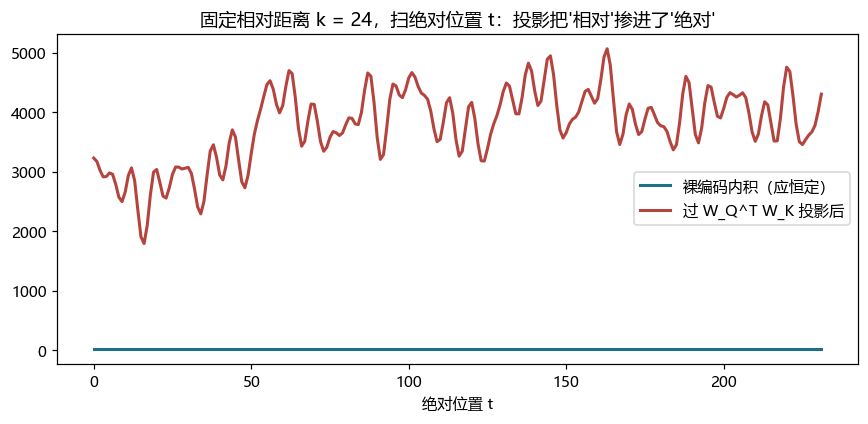

In [8]:
# 实验 7：W_Q^T W_K 投影会破坏"内积只依赖距离"——这正是 RoPE / RPE 的动机
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

d_model, N = 64, 256
pos = np.arange(N)[:, None]
angles = pos / 10000 ** (np.arange(0, d_model, 2)[None, :] / d_model)
P = np.zeros((N, d_model))
P[:, 0::2] = np.sin(angles)
P[:, 1::2] = np.cos(angles)

rng = np.random.default_rng(0)
W = rng.normal(scale=1.0 / np.sqrt(d_model), size=(d_model, d_model))   # 模拟一对 W_Q^T W_K
M = W @ W.T

k = 24                                        # 固定相对距离，只扫绝对位置
t_range = np.arange(0, N - k)
raw = np.einsum("td,td->t", P[t_range], P[t_range + k])                 # 裸内积 <p_t, p_{t+k}>
proj = np.einsum("td,de,se->t", P[t_range], M, P[t_range + k])          # 投影后 <p_t M, p_{t+k} M>

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_range, raw, lw=2, color="#1f6f8b", label="裸编码内积（应恒定）")
ax.plot(t_range, proj, lw=2, color="#b5443f", label="过 W_Q^T W_K 投影后")
ax.set_title(f"固定相对距离 k = {k}，扫绝对位置 t：投影把'相对'掺进了'绝对'")
ax.set_xlabel("绝对位置 t")
ax.legend()
plt.tight_layout()
plt.show()

print(f"固定相对距离 k = {k}，令 t 从 0 扫到 {N - k - 1}：")
print(f"  裸编码内积波动 std = {raw.std():.2e}   → 平移不变成立 ✓")
print(f"  投影后内积波动 std = {proj.std():.2e}   → 混入了绝对位置痕迹")
print()
print("结论：'加上去'的位置编码，其相对性会被 Q/K 投影稀释、破坏；")
print("想精确控制相对位置，就得绕过投影直接设计打分项 → 下一节的 NoPE / RPE / RoPE.")


## 8. 反直觉：不加位置编码行不行？——NoPE

2022 年起的研究（Haviv et al., *Transformer Language Models without Positional Encodings Still Learn Positional Information*）发现一个意外：**decoder-only 模型完全去掉位置编码，照样能学到顺序**。原因藏在因果掩码里：

1. **归一化不对称**：softmax 的分母只对"可见 token"求和——位置越靠前，能看到的 token 越少、分母越小。注意力分布因此被间接"盖了章"，因果掩码本身就打破了置换不变性。
2. **内容自带时序**：语料中词序共现本身是统计线索（"新年快乐"与"快乐新年"的频率天差地别），模型可以借内容推断顺序。

代价与边界：

| 场景 | 结论 |
| --- | --- |
| decoder-only + 因果掩码（GPT 类） | 能学，但位置分辨率粗糙——区分相邻位置主要靠内容差异，且精度随序列变长恶化 |
| encoder-only / 双向注意力（BERT 类） | **必须显式加**——没有因果掩码，彻底退回词袋 |
| 实际工程 | 显式编码收敛更快、位置区分更准，主流模型仍保留 |

> 一句话：因果掩码免费送了一份"模糊的"顺序感（NoPE 可行），但显式编码给得更准、更省——encoder 别想逃，decoder 用了也更好。

## 9. 显式相对位置：RPE 家族——把位置直接写进注意力

第 7 节四项分解的启示：与其把位置"加进词向量再祈祷投影手下留情"，不如**绕过投影，直接在打分上做文章**。加上第 8 节的教训（NoPE 模糊、encoder 无掩码可用），显式相对位置编码（RPE）成为主流。按注入方式分两大流派：

**流派一 · 偏置模式**：在打分上直接加一个只与位置差有关的标量，与内容项并行：

$$A_{t,s} = \frac{q_t^\top k_s}{\sqrt{d_{head}}} + b_{t-s}$$

- **T5 相对偏置**：把距离 $|t-s|$ 分桶，每桶学一个标量、所有注意力头共享——参数极少；
- **TUPE**：把"内容注意力"与"位置注意力"彻底解耦成两个独立项再相加；
- **ALiBi**：最激进——$b_{t-s} = -m\,|t-s|$，斜率 $m$ 按几何级数分给各头。**零训练参数**，线性惩罚远距离，训练短推理长时外推表现出色。

**流派二 · 上下文模式**：把相对位置向量织入 q/k 向量本身再做点积。代表：Shaw et al.（2018，首个可学习相对位置嵌入）、Transformer-XL（段循环 + 相对编码）、TENER、DeBERTa（内容与位置解耦打分）。

**流派三 · 旋转**：RoPE 把第 4 节实验 4 验证过的"位置前进 k = 平面旋转 k·c_i"直接变成实现——q、k 的每对维度乘旋转矩阵，打分 $q_t^\top R(t-s)\, k_s$ **精确只依赖 t−s**。LLaMA 系现代开源模型标配。

![](../src/transformer-8-13.jpg)

> 图：位置编码家族总览——从绝对到相对，从偏置到旋转。

| 方案 | 注入点 | 相对信息 | 外推能力 | 备注 |
| --- | --- | --- | --- | --- |
| 正弦 APE（哈佛版） | 词嵌入相加 | 隐式（会被投影稀释） | 可外推（有界公式） | 零参数，本文主角 |
| 可学习 APE | 词嵌入查表 | 无 | 差（受 max_len 限） | GPT-2 |
| T5 偏置 | 打分加标量 | 显式（分桶） | 中等 | 全头共享标量 |
| ALiBi | 打分加标量 | 显式（线性） | 强 | 零参数 |
| Shaw / Transformer-XL | 打分向量点积 | 显式（可学习） | 中等 | 首个 RPE |
| RoPE | Q/K 旋转 | 精确（每对维度） | 需缩放技巧（NTK/YaRN） | LLaMA 系标配 |

![](../src/positional-encoding-family.svg)

> **带走五句话**
>
> 1. 注意力对顺序"失明"（置换不变）——没有位置编码的 Transformer 是词袋，这是一切工作的出发点。
> 2. 正弦编码是一排时钟：低维"秒针"高频细分辨，高维"时针"低频粗定位，每个位置拿到唯一指纹。
> 3. 裸编码内积 $\langle PE_t, PE_{t+k}\rangle$ 只依赖距离 $k$ 且远程衰减——但过了 $W_Q, W_K$ 投影这份相对性会被破坏；RoPE / RPE 的动机正在于此。
> 4. 相加 = 拼接的特例（分块恒等式），$\sqrt{d_{model}}$ 让内容与位置同量级、互不淹没。
> 5. 因果掩码免费送模糊的顺序感（NoPE，encoder 没份）；要精确相对位置，就把第 (d) 项拎出来显式设计——T5 偏置、ALiBi、RoPE。

## 参考

- 教材《Transformer技术纵深》第 7 章（正弦编码）、第 8 章（位置编码家族），配图见 `../src/transformer-*.jpg`
- Vaswani et al., *Attention Is All You Need* (2017), §3.5
- Harvard NLP, *The Annotated Transformer* —— <https://nlp.seas.harvard.edu/annotated-transformer/>
- Haviv et al., *Transformer Language Models without Positional Encodings Still Learn Positional Information* (2022)